In [87]:
import pandas as pd
import pickle
import numpy as np
import os
from tableone import TableOne

output_base = 'output/data' 
df_raw = pickle.load(open(f'{output_base}/df_raw.pkl', "rb"))
df_ML = pickle.load(open(f'{output_base}/df_ML.pkl', "rb"))
# df_ML_unscaled = pickle.load(open(f'{output_base}/df_ML_unscaled.pkl', "rb"))
ML_feature_names = pickle.load(open(f'{output_base}/ML_feature_names.pkl', "rb"))
barpress_features_names = pickle.load(open(f'{output_base}/barpress_features_names.pkl', "rb"))

figure_path = 'output/figures'
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

In [88]:

from collections import OrderedDict


feature_name_map = OrderedDict([
    ('max_force', 'Max Force'),
    ('force_variation_rate', 'Force Variation Rate'),
    ('avg_first_5', 'Average First 5 Samples'),
    ('avg_last_5', 'Average Last 5 Samples'),
    ('pk_sharp_max', 'Max Peak Sharpness'),
    ('pk_sharp_mean', 'Mean Peak Sharpness'),
    ('pk_sharp_min', 'Min Peak Sharpness'),
    ('skewness', 'Skewness'),
    ('kurtosis', 'Kurtosis'),
    ('total_press_duration', 'Press Duration'),
    # ('gaps', 'Gap duration'),
    ('pk_num', 'Peak Number'),
    ('pk_widths_max', 'Max Peak Width'),
    ('pk_widths_mean', 'Mean Peak Width'),
    ('pk_widths_min', 'Min Peak Width')
])


if set(barpress_features_names) != set(feature_name_map.keys()):
    raise ValueError("The keys of feature_name_map must match the barpress_features_names.")


ordered_features = list(feature_name_map.keys())
ordered_features


['max_force',
 'force_variation_rate',
 'avg_first_5',
 'avg_last_5',
 'pk_sharp_max',
 'pk_sharp_mean',
 'pk_sharp_min',
 'skewness',
 'kurtosis',
 'total_press_duration',
 'pk_num',
 'pk_widths_max',
 'pk_widths_mean',
 'pk_widths_min']

In [89]:
# distribution of sex
df_raw2 = df_raw.drop_duplicates(subset=['id'])

continuous = ['age', 'weight']
categorical = ['sex', 'rat_type']
columns = continuous + categorical

table1 = TableOne(df_raw2, columns=columns, categorical=categorical, min_max= continuous)
print(table1.tabulate(tablefmt="github"))

|                        |                | Missing   | Overall             |
|------------------------|----------------|-----------|---------------------|
| n                      |                |           | 63                  |
| age, mean [min,max]    |                | 0         | 105.2 [56.0,180.0]  |
| weight, mean [min,max] |                | 0         | 225.2 [122.0,301.0] |
| sex, n (%)             | F              |           | 12 (19.0)           |
|                        | M              |           | 51 (81.0)           |
| rat_type, n (%)        | long-evans     |           | 19 (30.2)           |
|                        | sprague-dawley |           | 44 (69.8)           |


In [90]:
# number of sessions
print("total number of sessions: ", len(df_raw))
session_num = df_raw.groupby('category').count()['id'].to_dict()
print(f"number of sessions by group: {session_num}")


# average number of sessions per rat
sessions_per_rat = df_raw.groupby(['id', 'category','cohort']).size().reset_index(name='session_count')
avg_sessions_per_rat = sessions_per_rat.groupby(['category', 'cohort'])['session_count'].mean()
print(f"average number of sessions per rat by group: {avg_sessions_per_rat}")

total number of sessions:  186
number of sessions by group: {'EXT': 82, 'FR1': 104}
average number of sessions per rat by group: category  cohort
EXT       1         1.0
          2         1.0
          3         2.0
FR1       1         2.0
          2         1.0
          3         2.0
Name: session_count, dtype: float64


In [91]:
print("Total number of bar presses get removed due to constant force")
df_raw.bar_presses_constant_index.apply(lambda x: len(x)).agg(['sum']).to_dict()


print(f"total number of barpresses: {len(df_ML)}")
print(f"number of barpresses by group: {df_ML.groupby('category').count()['id'].to_dict()}")

Total number of bar presses get removed due to constant force
total number of barpresses: 24539
number of barpresses by group: {'EXT': 8421, 'FR1': 16118}


In [92]:
# session duration
df_session = df_ML.groupby(['file_name', 'id', 'category', 'cohort']).agg({'data_end_index': 'max'}).reset_index()

df_session['session_duration_min'] = df_session['data_end_index'] / 100 / 60

print("average session duration (min) by group:")
print(df_session.groupby('category')['session_duration_min'].mean())


print("average session duration (min) by group and cohort:")
print(df_session.groupby(['category', 'cohort'])['session_duration_min'].mean())


average session duration (min) by group:
category
EXT    28.066354
FR1    12.543082
Name: session_duration_min, dtype: float64
average session duration (min) by group and cohort:
category  cohort
EXT       1         28.459038
          2         26.359061
          3         28.827443
FR1       1         14.594083
          2          4.931394
          3         14.575004
Name: session_duration_min, dtype: float64


In [93]:
df_ML.groupby('category')['total_press_duration'].agg(
    ['mean', 'std','min','max']
)

,mean,std,min,max
category,,,,
EXT,68.780074,55.991564,10,482
FR1,57.407743,49.674145,10,498


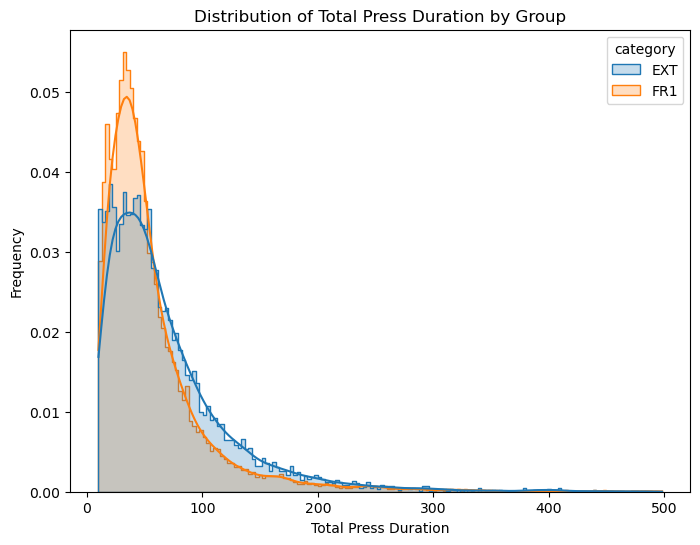

In [94]:
# distribution of total press duration by group
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.histplot(
    data=df_ML,
    x='total_press_duration',
    hue='category',
    kde=True,
    element='step',
    stat='probability',
    common_norm=False
)
plt.title('Distribution of Total Press Duration by Group')
plt.xlabel('Total Press Duration')
plt.ylabel('Frequency')
plt.show()

# Descriptive table for features

In [95]:
import pandas as pd
from scipy.stats import ttest_ind


results = []

for feat in ordered_features:
    fr1 = df_ML[df_ML['category'] == 'FR1'][feat].dropna()
    ext = df_ML[df_ML['category'] == 'EXT'][feat].dropna()
    
    # Descriptive stats
    fr1_mean, fr1_sd = fr1.mean(), fr1.std()
    ext_mean, ext_sd = ext.mean(), ext.std()
    
    # Welch’s t-test
    t_stat, p_val = ttest_ind(fr1, ext, equal_var=False)
    
    results.append({
        'Feature': feature_name_map.get(feat, feat),
        'FR1 (Mean ± SD)': f"{fr1_mean:.2f} ± {fr1_sd:.2f}",
        'EXT (Mean ± SD)': f"{ext_mean:.2f} ± {ext_sd:.2f}",
        'P-value': "$<$0.001" if p_val < 0.001 else f"{p_val:.3f}"
    })

# Create final table
df_table = pd.DataFrame(results)

# Display in notebook
display(df_table)

# Optional: export to LaTeX
latex_table = df_table.to_latex(index=False, escape=False)
print(latex_table)

,Feature,FR1 (Mean ± SD),EXT (Mean ± SD),P-value
0,Max Force,46.67 ± 45.13,45.33 ± 35.55,0.011
1,Force Variation Rate,8.75 ± 12.75,7.96 ± 9.68,$<$0.001
2,Average First 5 Samples,14.81 ± 5.97,15.49 ± 5.81,$<$0.001
3,Average Last 5 Samples,14.76 ± 18.43,14.33 ± 14.94,0.049
4,Max Peak Sharpness,3.56 ± 6.52,2.98 ± 4.85,$<$0.001
5,Mean Peak Sharpness,3.36 ± 6.34,2.72 ± 4.70,$<$0.001
6,Min Peak Sharpness,3.19 ± 6.29,2.49 ± 4.66,$<$0.001
7,Skewness,-0.01 ± 0.66,-0.10 ± 0.68,$<$0.001
8,Kurtosis,-0.52 ± 1.04,-0.33 ± 1.14,$<$0.001
9,Press Duration,57.41 ± 49.67,68.78 ± 55.99,$<$0.001


\begin{tabular}{llll}
\toprule
Feature & FR1 (Mean ± SD) & EXT (Mean ± SD) & P-value \\
\midrule
Max Force & 46.67 ± 45.13 & 45.33 ± 35.55 & 0.011 \\
Force Variation Rate & 8.75 ± 12.75 & 7.96 ± 9.68 & $<$0.001 \\
Average First 5 Samples & 14.81 ± 5.97 & 15.49 ± 5.81 & $<$0.001 \\
Average Last 5 Samples & 14.76 ± 18.43 & 14.33 ± 14.94 & 0.049 \\
Max Peak Sharpness & 3.56 ± 6.52 & 2.98 ± 4.85 & $<$0.001 \\
Mean Peak Sharpness & 3.36 ± 6.34 & 2.72 ± 4.70 & $<$0.001 \\
Min Peak Sharpness & 3.19 ± 6.29 & 2.49 ± 4.66 & $<$0.001 \\
Skewness & -0.01 ± 0.66 & -0.10 ± 0.68 & $<$0.001 \\
Kurtosis & -0.52 ± 1.04 & -0.33 ± 1.14 & $<$0.001 \\
Press Duration & 57.41 ± 49.67 & 68.78 ± 55.99 & $<$0.001 \\
Peak Number & 1.32 ± 0.94 & 1.52 ± 1.08 & $<$0.001 \\
Max Peak Width & 21.01 ± 15.25 & 25.66 ± 20.35 & $<$0.001 \\
Mean Peak Width & 19.04 ± 12.66 & 21.69 ± 15.77 & $<$0.001 \\
Min Peak Width & 17.48 ± 12.72 & 18.53 ± 15.86 & $<$0.001 \\
\bottomrule
\end{tabular}



# Headmap

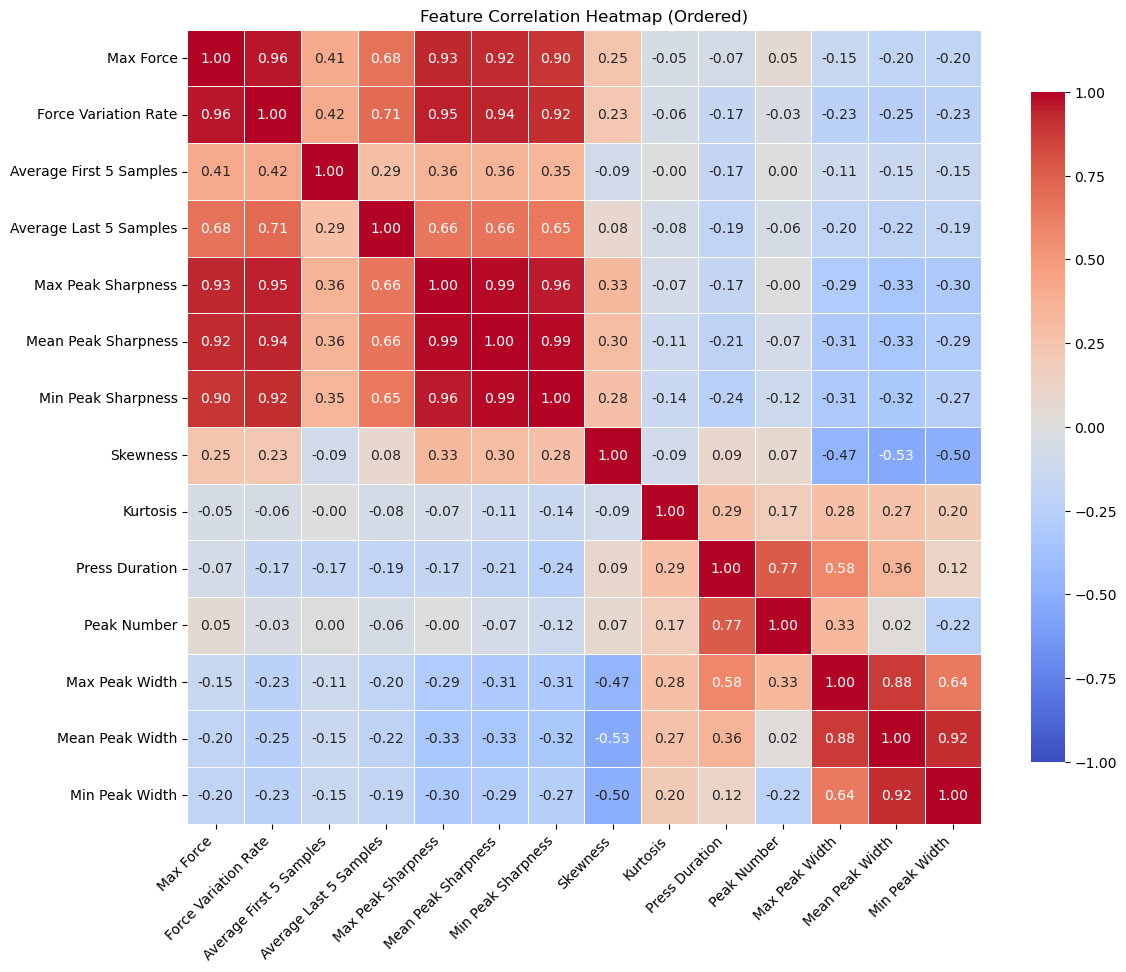

In [96]:
# Select + reorder + rename
df_features = df_ML[ordered_features].copy()
df_features.rename(columns=feature_name_map, inplace=True)

# Correlation
corr_matrix = df_features.corr()

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',   
    vmin=-1, vmax=1,   
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Feature Correlation Heatmap (Ordered)")
plt.tight_layout()
plt.savefig(f"{figure_path}/correlation.png", dpi=300, bbox_inches='tight')
plt.show()

# Model Evaluation (outdated, see models.ipynb)

In [97]:
df_ML_train = pickle.load(open(f'{output_base}/df_ML_train.pkl', "rb"))
x_train = df_ML_train[ML_feature_names]
y_train = df_ML_train['label'].to_numpy()
sample_weights = df_ML_train['sample_weight']

df_ML_test = pickle.load(open(f'{output_base}/df_ML_test.pkl', "rb"))
x_test = df_ML_test[ML_feature_names]
y_test = df_ML_test['label'].to_numpy()
sample_weights_test = df_ML_test['sample_weight']

ML_feature_names


['total_press_duration',
 'max_force',
 'pk_num',
 'pk_widths_max',
 'pk_widths_mean',
 'pk_widths_min',
 'pk_sharp_max',
 'pk_sharp_mean',
 'pk_sharp_min',
 'skewness',
 'kurtosis',
 'force_variation_rate',
 'avg_first_5',
 'avg_last_5',
 'sex',
 'age',
 'weight',
 'rat_type']

In [98]:
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score

def calc_metrics(y_true, y_prob):
    thresholds = np.unique(y_prob)
    best_threshold = 0.5
    best_f1 = -1.0

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred_t, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = float(t)

    y_pred_t = (y_prob >= best_threshold).astype(int)
    f1 = f1_score(y_true, y_pred_t, zero_division=0)
    recall = recall_score(y_true, y_pred_t, zero_division=0)
    precision = precision_score(y_true, y_pred_t, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    return {
        "threshold": round(best_threshold, 3),
        "f1_score": round(f1, 3),
        "recall": round(recall, 3),
        "precision": round(precision, 3),
        "auc": round(auc, 3),
    }

In [99]:
import xgboost as xgb

gb = xgb.XGBClassifier(
    tree_method="hist",
    random_state=42
)


gb.fit(x_train, y_train, sample_weight=sample_weights)
y_pred = gb.predict_proba(x_test)[:, 1]
GB_metrics = calc_metrics(y_test, y_pred)
print(GB_metrics)


{'threshold': 0.24, 'f1_score': 0.595, 'recall': 0.89, 'precision': 0.447, 'auc': 0.614}
